# Aupa — Modelo 2: Clustering de Perfiles de Usuario con KMeans
### Reto Inetum · Bootcamp BBK The Bridge · Equipo 4 Data
**Lead:** Naia | **Equipo:** Andoni, Unai, Fátima | **Fecha:** Junio 2026

---

Este notebook construye el modelo de segmentación de usuarios de Aupa. El objetivo es que cuando alguien completa el onboarding de la app (elige sus preferencias, cuánto tiempo se queda y con quién viaja), el sistema le asigne automáticamente a un perfil y le muestre los lugares ordenados por relevancia para ese perfil.

Como todavía no tenemos usuarios reales, generamos 1.000 usuarios sintéticos basados en los 5 arquetipos que definimos durante el diseño del producto. Luego aplicamos KMeans con el método del codo y el coeficiente de silhouette para encontrar el número óptimo de clusters.


## Diseño del vector de usuario

### Datos sintéticos vs. producción

El vector tiene **17 dimensiones** en total:

| Bloque | Dimensiones | Tipo en sintéticos | Tipo en producción |
|---|---|---|---|
| Preferencias | 15 | Continuo Beta [0,1] | Binario: 3 unos, 12 ceros |
| Duración | 1 | Continuo [0.25–1.0] | One-hot: 1 de 4 opciones |
| Compañía | 1 | Continuo [0.25–1.0] | One-hot: 1 de 4 opciones |

**¿Por qué esta diferencia entre sintéticos y producción no es un problema?**

Los datos sintéticos usan distribuciones Beta continuas para maximizar la separabilidad de los clusters durante el entrenamiento. Esto es válido porque el `StandardScaler` aprende la distribución del conjunto de entrenamiento (valores 0–1 continuos) y aplica exactamente la misma transformación a los datos de producción. Un vector binario real está dentro del mismo rango [0,1], simplemente en los extremos. El `predict()` opera sobre el espacio escalado, que es el mismo en ambos casos.

En producción, `duration` y `companion` se codifican como valores ordinales en [0.25, 0.50, 0.75, 1.0] antes de escalar, igual que en los sintéticos.

**Restricción del onboarding:** el usuario elige exactamente 3 preferencias de las 15 disponibles. Forzar exactamente 3 (no "hasta 3") garantiza que todos los vectores de producción tengan la misma densidad, lo que hace las distancias comparables entre usuarios.


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'font.family': 'sans-serif',
})

PREFS = [
    'food', 'culture', 'nature', 'bars', 'local_favorites',
    'shopping', 'coffee_shops', 'walking_tours', 'family_friendly',
    'vegetarian_vegan', 'history', 'festivals_events', 'beaches',
    'nightlife', 'budget_friendly'
]

DIMS = PREFS + ['duration', 'companion']

# Opciones reales del onboarding (para la función de predicción)
DURATION_MAP  = {'oneday': 0.25, 'threedays': 0.50, 'oneweek': 0.75, 'longstay': 1.0}
COMPANION_MAP = {'solo':  0.25, 'partner':   0.50, 'friends':   0.75, 'family':  1.0}

PALETTE = ['#D85A30', '#1D9E75', '#7F77DD', '#EF9F27', '#378ADD', '#888780']

print(f"Dimensiones del vector: {len(DIMS)}")
print(f"  Preferencias : {len(PREFS)} (continuas en sintéticos, binarias en producción)")
print(f"  duration     : 1  (continua en sintéticos, ordinal en producción)")
print(f"  companion    : 1  (continua en sintéticos, ordinal en producción)")
print()
print(f"Mapeo duration  : {DURATION_MAP}")
print(f"Mapeo companion : {COMPANION_MAP}")


Dimensiones del vector: 17
  Preferencias : 15 (continuas en sintéticos, binarias en producción)
  duration     : 1  (continua en sintéticos, ordinal en producción)
  companion    : 1  (continua en sintéticos, ordinal en producción)

Mapeo duration  : {'oneday': 0.25, 'threedays': 0.5, 'oneweek': 0.75, 'longstay': 1.0}
Mapeo companion : {'solo': 0.25, 'partner': 0.5, 'friends': 0.75, 'family': 1.0}


## Perfiles base para la generación sintética

Definimos 5 arquetipos de usuario. Cada uno tiene probabilidades específicas para cada preferencia, que se usan como parámetros de una distribución Beta: valores altos generan muestras cercanas a 1 (preferencia fuerte), valores bajos generan muestras cercanas a 0.

Para `duration` y `companion` usamos una función discreta con ruido que convierte la probabilidad base en uno de los cuatro valores ordinales [0.25, 0.50, 0.75, 1.0].


In [2]:
PROFILES = {
    'gastro': {
        'food': 0.90, 'bars': 0.85, 'local_favorites': 0.80,
        'coffee_shops': 0.65, 'vegetarian_vegan': 0.35,
        'culture': 0.30, 'budget_friendly': 0.50,
        'walking_tours': 0.30, 'history': 0.20,
        'nature': 0.10, 'shopping': 0.20,
        'family_friendly': 0.10, 'nightlife': 0.30,
        'beaches': 0.10, 'festivals_events': 0.30,
        'duration': 0.50, 'companion': 0.50,   # viajes cortos, pareja/amigos
    },
    'cultural': {
        'culture': 0.92, 'history': 0.88, 'walking_tours': 0.78,
        'festivals_events': 0.72, 'local_favorites': 0.58,
        'food': 0.50, 'coffee_shops': 0.55, 'budget_friendly': 0.38,
        'nature': 0.30, 'shopping': 0.22,
        'bars': 0.22, 'family_friendly': 0.18,
        'nightlife': 0.10, 'beaches': 0.10,
        'vegetarian_vegan': 0.12,
        'duration': 0.75, 'companion': 0.50,   # estancias medias, solo/pareja
    },
    'naturaleza': {
        'nature': 0.93, 'beaches': 0.78, 'walking_tours': 0.73,
        'local_favorites': 0.48, 'budget_friendly': 0.62,
        'food': 0.38, 'family_friendly': 0.42,
        'culture': 0.28, 'festivals_events': 0.18,
        'coffee_shops': 0.22, 'history': 0.18,
        'bars': 0.12, 'shopping': 0.08,
        'nightlife': 0.05, 'vegetarian_vegan': 0.33,
        'duration': 0.75, 'companion': 0.75,   # estancias largas, amigos/familia
    },
    'familiar': {
        'family_friendly': 0.93, 'nature': 0.68, 'beaches': 0.62,
        'food': 0.63, 'budget_friendly': 0.78, 'walking_tours': 0.42,
        'culture': 0.42, 'shopping': 0.38,
        'local_favorites': 0.32, 'festivals_events': 0.48,
        'coffee_shops': 0.32, 'history': 0.22,
        'vegetarian_vegan': 0.18, 'bars': 0.08,
        'nightlife': 0.02,
        'duration': 0.50, 'companion': 1.0,    # siempre familia
    },
    'nocturno': {
        'nightlife': 0.93, 'bars': 0.88, 'food': 0.68,
        'festivals_events': 0.62, 'budget_friendly': 0.52,
        'coffee_shops': 0.38, 'local_favorites': 0.48,
        'shopping': 0.32, 'culture': 0.18,
        'walking_tours': 0.18, 'nature': 0.08,
        'beaches': 0.12, 'family_friendly': 0.04,
        'history': 0.08, 'vegetarian_vegan': 0.12,
        'duration': 0.25, 'companion': 0.75,   # viajes muy cortos, amigos
    },
}

print("Perfiles definidos:")
for nombre, perfil in PROFILES.items():
    top3 = sorted(perfil.items(), key=lambda x: -x[1])[:3]
    top3_str = ", ".join([f"{k}={v}" for k, v in top3])
    print(f"  {nombre:12s} → top 3: {top3_str}")


Perfiles definidos:
  gastro       → top 3: food=0.9, bars=0.85, local_favorites=0.8
  cultural     → top 3: culture=0.92, history=0.88, walking_tours=0.78
  naturaleza   → top 3: nature=0.93, beaches=0.78, duration=0.75
  familiar     → top 3: companion=1.0, family_friendly=0.93, budget_friendly=0.78
  nocturno     → top 3: nightlife=0.93, bars=0.88, companion=0.75


## Generación de usuarios sintéticos

Para cada perfil generamos 200 usuarios usando:
- **Distribución Beta** para las 15 preferencias: `alpha = prob * 8`, `beta = (1-prob) * 8`. A mayor probabilidad, las muestras se concentran cerca de 1.
- **Función discreta con ruido** para `duration` y `companion`: convierte la probabilidad base en uno de los cuatro valores ordinales con algo de variabilidad.


In [3]:
def sample_discrete(base_prob, options=[0.25, 0.50, 0.75, 1.0]):
    """
    Convierte una probabilidad base [0,1] en un valor ordinal discreto con ruido.
    Mapea la prob a un índice en options, luego añade ±1 de ruido aleatorio.
    """
    idx = min(int(base_prob * len(options)), len(options) - 1)
    noise = np.random.randint(-1, 2)
    idx = max(0, min(len(options) - 1, idx + noise))
    return options[idx]

np.random.seed(42)
users = []

for profile_name, profile in PROFILES.items():
    for _ in range(200):
        user = {}
        for dim in PREFS:
            base_prob = profile.get(dim, 0.3)
            alpha = max(0.5, base_prob * 8)
            beta  = max(0.5, (1 - base_prob) * 8)
            user[dim] = round(float(np.random.beta(alpha, beta)), 4)
        user['duration']      = sample_discrete(profile.get('duration',  0.5))
        user['companion']     = sample_discrete(profile.get('companion', 0.5))
        user['profile_true']  = profile_name
        users.append(user)

df_users = pd.DataFrame(users)

print(f"Usuarios generados: {len(df_users):,}")
print(f"Distribución por perfil:")
print(df_users['profile_true'].value_counts().to_string())
print()
print("Vista de los primeros 3 usuarios:")
print(df_users[DIMS].head(3).to_string())


Usuarios generados: 1,000
Distribución por perfil:
profile_true
gastro        200
cultural      200
naturaleza    200
familiar      200
nocturno      200

Vista de los primeros 3 usuarios:
     food  culture  nature    bars  local_favorites  shopping  coffee_shops  walking_tours  family_friendly  vegetarian_vegan  history  festivals_events  beaches  nightlife  budget_friendly  duration  companion
0  0.9218   0.1607  0.2874  0.9144           0.7884    0.1336        0.8570         0.1165           0.3921            0.2963   0.0470            0.2157   0.1471     0.3693           0.5251      0.50       0.75
1  0.9695   0.5737  0.0013  0.7393           0.7824    0.1896        0.7060         0.2421           0.0087            0.4072   0.1410            0.4669   0.0240     0.2030           0.7670      1.00       1.00
2  0.8828   0.1489  0.0606  0.9767           0.7770    0.2872        0.6963         0.4539           0.0567            0.4371   0.3404            0.3925   0.2898     0.4946      

## Visualización de los perfiles generados

Comprobamos que los perfiles sintéticos tienen las distribuciones esperadas. Si los boxplots muestran diferencias claras entre perfiles en las dimensiones clave, la generación es correcta.


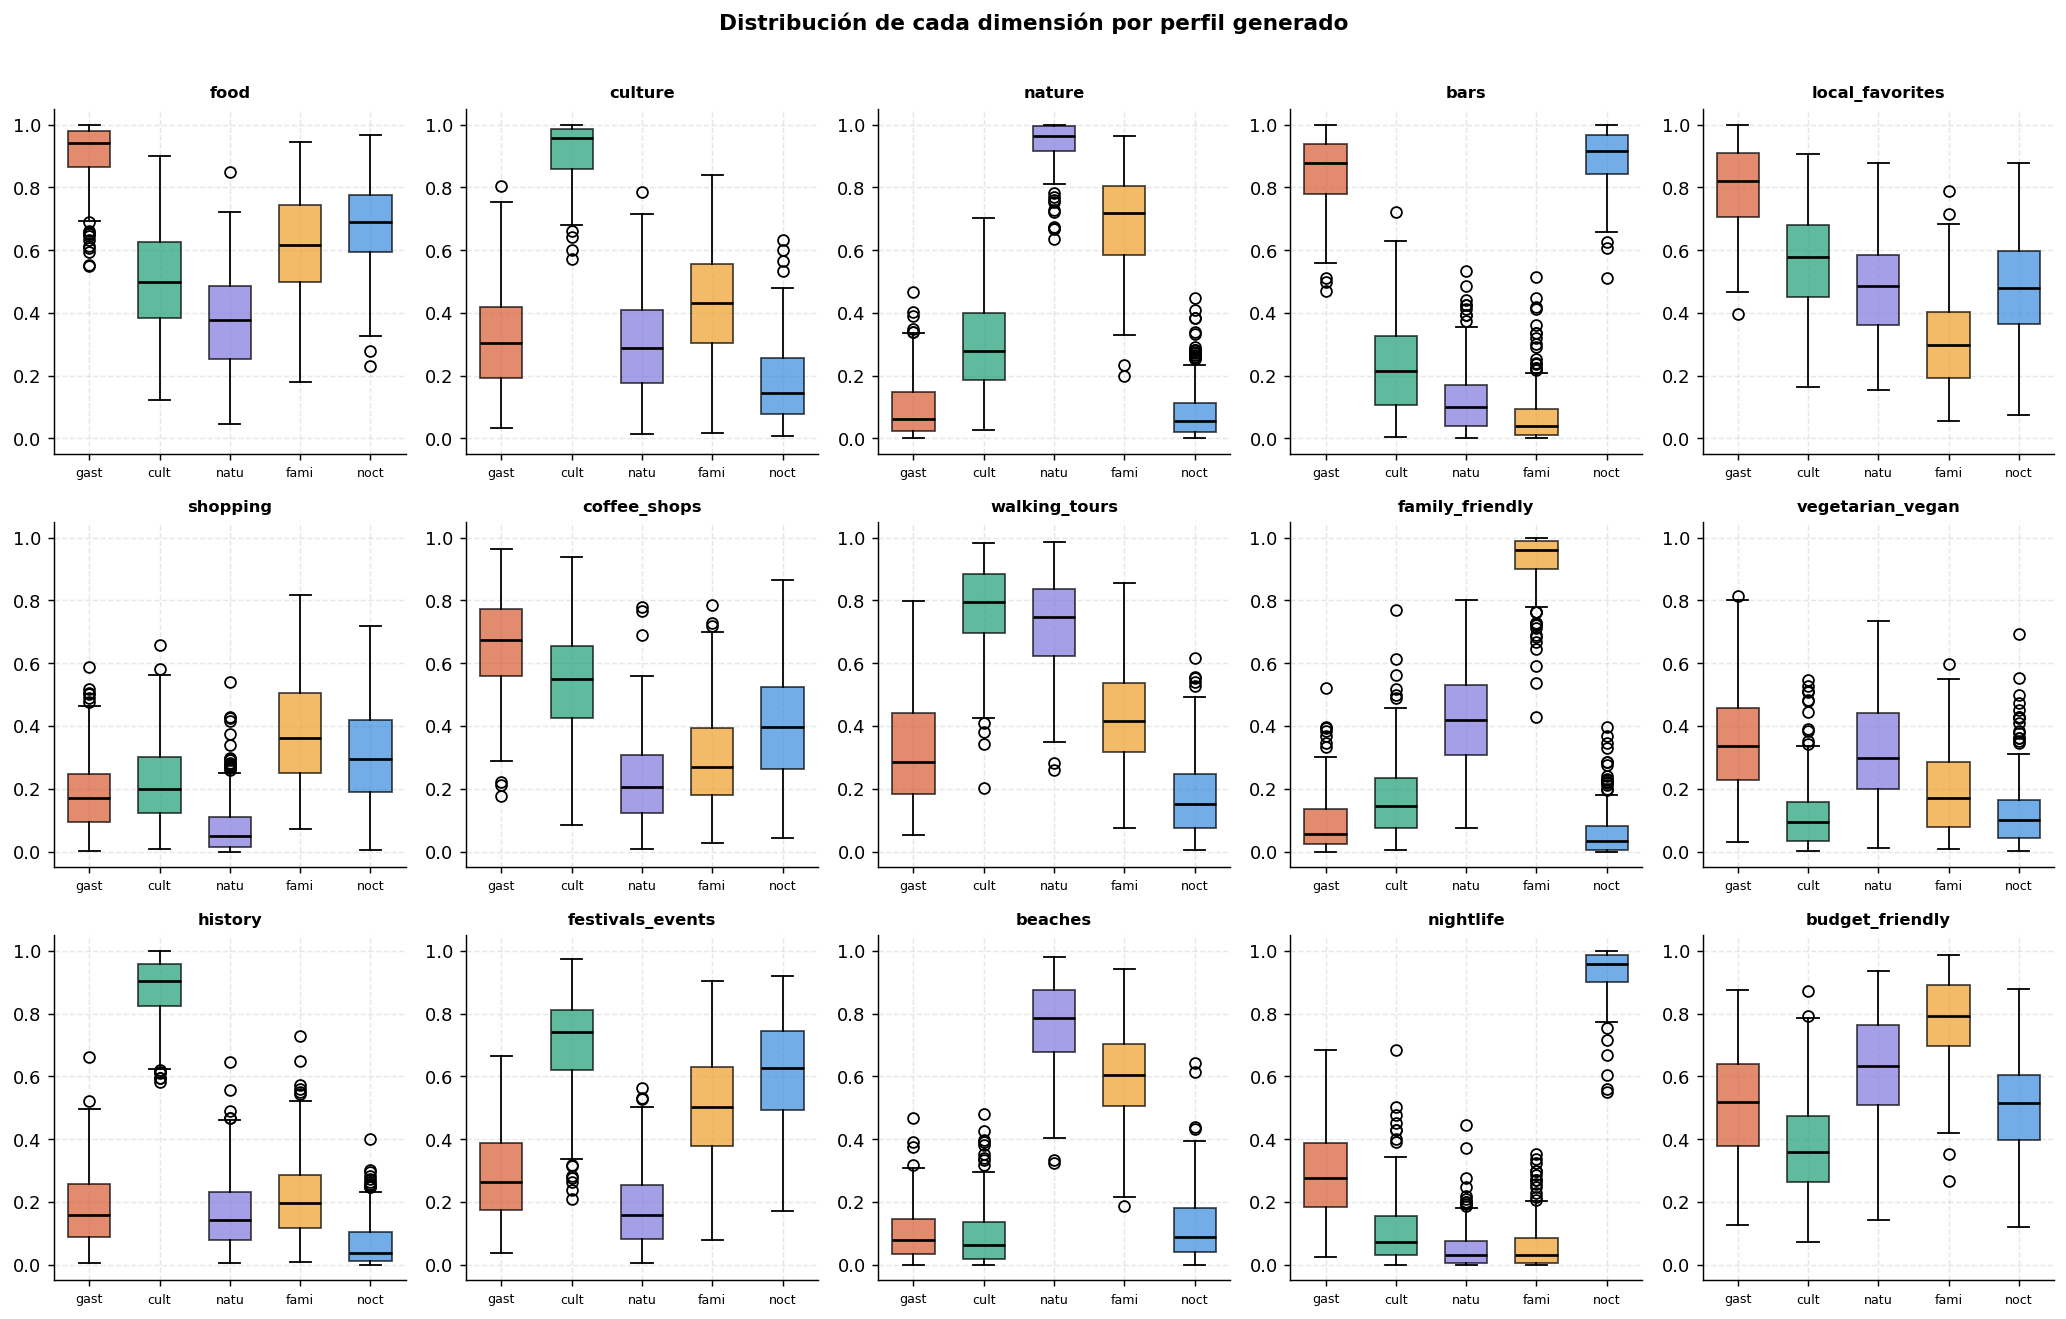

In [4]:
fig, axes = plt.subplots(3, 5, figsize=(16, 10))

for idx, dim in enumerate(PREFS):
    ax = axes[idx // 5][idx % 5]
    data_by_profile = [df_users[df_users['profile_true'] == p][dim].values
                       for p in PROFILES.keys()]
    bp = ax.boxplot(data_by_profile, patch_artist=True, widths=0.6,
                    medianprops={'color': 'black', 'linewidth': 1.5})
    for patch, color in zip(bp['boxes'], PALETTE):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(dim, fontsize=9, fontweight='bold')
    ax.set_xticks(range(1, 6))
    ax.set_xticklabels([p[:4] for p in PROFILES.keys()], fontsize=7)
    ax.set_ylim(-0.05, 1.05)

plt.suptitle('Distribución de cada dimensión por perfil generado',
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_distribucion_perfiles.png', bbox_inches='tight', dpi=130)
plt.show()


## KMeans: método del codo y silhouette

Entrenamos KMeans con K entre 2 y 10. Para cada K calculamos:
- **Inercia**: suma de distancias al cuadrado de cada punto a su centroide. Buscamos el "codo" donde la bajada se aplana.
- **Silhouette score**: mide qué tan bien separados están los clusters. Entre -1 y 1, valores más altos son mejores.


In [5]:
X_cluster = df_users[DIMS].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

inertias    = []
silhouettes = []
K_RANGE     = range(2, 11)

print(f"{'K':>4} {'Inercia':>12} {'Silhouette':>12}  {'Nota'}")
print("-" * 55)
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, labels)
    silhouettes.append(sil)
    nota = " ← óptimo" if sil == max(silhouettes) else ""
    print(f"{k:>4} {km.inertia_:>12.1f} {sil:>12.4f}  {nota}")


   K      Inercia   Silhouette  Nota
-------------------------------------------------------
   2      12236.5       0.2732   ← óptimo
   3       8907.8       0.3479   ← óptimo
   4       7467.1       0.3399  
   5       6232.4       0.3250  
   6       6008.3       0.2749  
   7       5867.9       0.2285  
   8       5680.7       0.1908  
   9       5557.8       0.1465  
  10       5484.8       0.1114  


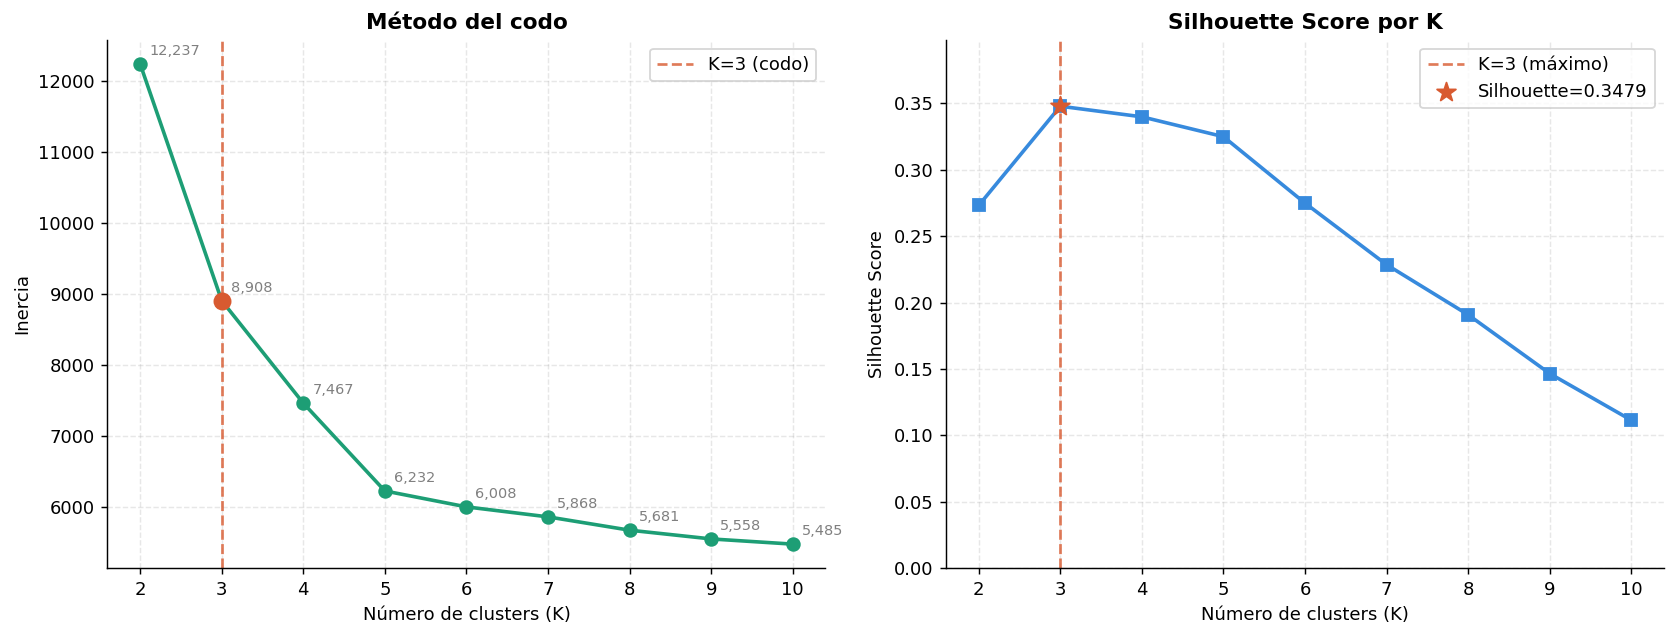

K óptimo: 3  (silhouette=0.3479)


In [6]:
k_list   = list(K_RANGE)
k_optimo = k_list[silhouettes.index(max(silhouettes))]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(k_list, inertias, 'o-', color=PALETTE[1], linewidth=2, markersize=7)
axes[0].axvline(k_optimo, color=PALETTE[0], linestyle='--', linewidth=1.5,
                alpha=0.8, label=f'K={k_optimo} (codo)')
axes[0].scatter([k_optimo], [inertias[k_optimo - 2]], color=PALETTE[0], zorder=5, s=80)
axes[0].set_xlabel('Número de clusters (K)')
axes[0].set_ylabel('Inercia')
axes[0].set_title('Método del codo', fontweight='bold')
axes[0].legend()
for k, v in zip(k_list, inertias):
    axes[0].annotate(f'{v:,.0f}', (k, v), textcoords='offset points',
                     xytext=(5, 5), fontsize=8, color='gray')

axes[1].plot(k_list, silhouettes, 's-', color=PALETTE[4], linewidth=2, markersize=7)
axes[1].axvline(k_optimo, color=PALETTE[0], linestyle='--', linewidth=1.5,
                alpha=0.8, label=f'K={k_optimo} (máximo)')
axes[1].scatter([k_optimo], [max(silhouettes)], color=PALETTE[0], zorder=5, s=120,
                marker='*', label=f'Silhouette={max(silhouettes):.4f}')
axes[1].set_xlabel('Número de clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score por K', fontweight='bold')
axes[1].legend()
axes[1].set_ylim(0, max(silhouettes) + 0.05)

plt.tight_layout()
plt.savefig('fig_elbow_silhouette.png', bbox_inches='tight', dpi=130)
plt.show()

print(f"K óptimo: {k_optimo}  (silhouette={max(silhouettes):.4f})")


## Modelo final y análisis de clusters

Entrenamos el modelo final con el K óptimo. La tabla de contingencia cruza los perfiles verdaderos de generación con los clusters asignados por KMeans — esto valida que el modelo ha encontrado agrupaciones coherentes con los arquetipos diseñados.


In [7]:
km_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=20)
labels_final = km_final.fit_predict(X_scaled)
sil_final = silhouette_score(X_scaled, labels_final)

df_users['cluster'] = labels_final

print(f"Modelo final: K={k_optimo}, silhouette={sil_final:.4f}")
print()
print("Composición de cada cluster (perfil verdadero vs cluster asignado):")
ct = pd.crosstab(df_users['profile_true'], df_users['cluster'],
                 rownames=['Perfil generado'], colnames=['Cluster KMeans'])
print(ct)
print()
print("Interpretación esperada:")
print("  gastro + nocturno     → comparten bars/food → mismo cluster (Txoko Social)")
print("  naturaleza + familiar → comparten nature/beaches → mismo cluster (Mendi & Familia)")
print("  cultural              → dimensiones únicas → cluster propio (Kultura)")


Modelo final: K=3, silhouette=0.3479

Composición de cada cluster (perfil verdadero vs cluster asignado):
Cluster KMeans     0    1    2
Perfil generado               
cultural           0    0  200
familiar           0  200    0
gastro           200    0    0
naturaleza         0  200    0
nocturno         200    0    0

Interpretación esperada:
  gastro + nocturno     → comparten bars/food → mismo cluster (Txoko Social)
  naturaleza + familiar → comparten nature/beaches → mismo cluster (Mendi & Familia)
  cultural              → dimensiones únicas → cluster propio (Kultura)


In [8]:
centroids_scaled = km_final.cluster_centers_
centroids_orig   = scaler.inverse_transform(centroids_scaled)
df_centroids     = pd.DataFrame(centroids_orig, columns=DIMS)

NOMBRES_CLUSTER = {}
for cluster_id in range(k_optimo):
    centroid   = df_centroids.iloc[cluster_id]
    top5_prefs = centroid[PREFS].nlargest(5)
    n          = sum(labels_final == cluster_id)
    NOMBRES_CLUSTER[cluster_id] = {
        'n': n,
        'top5': top5_prefs,
    }
    print(f"Cluster {cluster_id}  ({n} usuarios)")
    print(f"  Top 5 preferencias:")
    for dim, val in top5_prefs.items():
        print(f"    {dim:20s}: {val:.3f}")
    dur_val  = centroid['duration']
    comp_val = centroid['companion']
    dur_label  = min(DURATION_MAP,  key=lambda x: abs(DURATION_MAP[x]  - dur_val))
    comp_label = min(COMPANION_MAP, key=lambda x: abs(COMPANION_MAP[x] - comp_val))
    print(f"  Duración dominante : {dur_label}  ({dur_val:.2f})")
    print(f"  Compañía dominante : {comp_label}  ({comp_val:.2f})")
    print()


Cluster 0  (400 usuarios)
  Top 5 preferencias:
    bars                : 0.871
    food                : 0.791
    local_favorites     : 0.637
    nightlife           : 0.612
    coffee_shops        : 0.529
  Duración dominante : 2_3_dias  (0.61)
  Compañía dominante : amigos  (0.83)

Cluster 1  (400 usuarios)
  Top 5 preferencias:
    nature              : 0.814
    budget_friendly     : 0.698
    beaches             : 0.688
    family_friendly     : 0.675
    walking_tours       : 0.575
  Duración dominante : 4_7_dias  (0.84)
  Compañía dominante : familia  (0.91)

Cluster 2  (200 usuarios)
  Top 5 preferencias:
    culture             : 0.912
    history             : 0.879
    walking_tours       : 0.773
    festivals_events    : 0.699
    local_favorites     : 0.562
  Duración dominante : mas_de_7  (0.91)
  Compañía dominante : amigos  (0.74)



## Nombrado de clusters y mapeo a categorías de Aupa

Asignamos nombres a cada cluster basándonos en sus dimensiones dominantes y definimos qué subcategorías del dataset recomienda cada perfil. Este mapeo es la pieza que conecta el modelo con la app.


In [9]:
# Ajustar los nombres según el análisis de centroides anterior
NOMBRE_POR_CLUSTER = {
    0: 'Txoko Social',
    1: 'Mendi & Familia',
    2: 'Kultura',
}

CLUSTER_TO_CATEGORIAS = {
    'Txoko Social': {
        'subcategorias': [
            'Restaurantes / Asadores / Sidrerías',
            'Bares de pintxos',
            'Queserías / Conserveras / Productores',
            'Gastronomía general',
            'Tiendas gourmet y enotecas',
            'Pastelerías y confiterías',
            'Ocio general',
            'Hipódromos y estadios',
            'Recintos feriales',
        ],
        'vibes': ['For Foodies', 'Local Favorites', 'Pintxo Crawl'],
        'companion_hint': 'pareja o amigos',
        'duration_hint': '2-3 días',
    },
    'Mendi & Familia': {
        'subcategorias': [
            'Alojamientos rurales',
            'Recursos deportivos',
            'Turismo activo (kayak, surf, escalada...)',
            'Espacios naturales',
            'Parques naturales',
            'Campings',
            'Alquiler deportivo',
            'Rutas y paseos',
            'Puertos deportivos / Náutica',
            'Centros BTT',
            'Palacios de hielo',
            'Parques de atracciones',
            'Aquariums',
            'Turismo de salud / Spas',
        ],
        'vibes': ['For the Outdoors', 'Family Day', 'Active Weekend'],
        'companion_hint': 'familia o amigos',
        'duration_hint': '4-7 días',
    },
    'Kultura': {
        'subcategorias': [
            'Museos y centros de interpretación',
            'Edificios religiosos / Castillos',
            'Recursos culturales generales',
            'Cuevas y restos arqueológicos',
            'Auditorios',
            'Palacios de congresos',
            'Patrimonio y recursos culturales',
        ],
        'vibes': ['For Culture Lovers', 'Walking Tours', 'History & Art'],
        'companion_hint': 'pareja o solo',
        'duration_hint': '1-3 días',
    },
}

for cluster_id, nombre in NOMBRE_POR_CLUSTER.items():
    info = NOMBRES_CLUSTER.get(cluster_id, {})
    cats = CLUSTER_TO_CATEGORIAS[nombre]
    print(f"Cluster {cluster_id} → {nombre}  ({info.get('n','?')} usuarios)")
    print(f"  Subcategorías: {', '.join(cats['subcategorias'][:3])}...")
    print(f"  Vibes: {', '.join(cats['vibes'])}")
    print(f"  Compañía: {cats['companion_hint']} | Duración: {cats['duration_hint']}")
    print()


Cluster 0 → Txoko Social  (400 usuarios)
  Subcategorías: Restaurantes / Asadores / Sidrerías, Bares de pintxos, Queserías / Conserveras / Productores...
  Vibes: For Foodies, Local Favorites, Pintxo Crawl
  Compañía: pareja o amigos | Duración: 2-3 días

Cluster 1 → Mendi & Familia  (400 usuarios)
  Subcategorías: Alojamientos rurales, Recursos deportivos, Turismo activo (kayak, surf, escalada...)...
  Vibes: For the Outdoors, Family Day, Active Weekend
  Compañía: familia o amigos | Duración: 4-7 días

Cluster 2 → Kultura  (200 usuarios)
  Subcategorías: Museos y centros de interpretación, Edificios religiosos / Castillos, Recursos culturales generales...
  Vibes: For Culture Lovers, Walking Tours, History & Art
  Compañía: pareja o solo | Duración: 1-3 días



## Visualizaciones del modelo final

### Gráfico radar de centroides
Muestra el perfil de cada cluster en las dimensiones principales.

### Análisis de silhouette por cluster
Muestra qué tan bien encaja cada usuario en su cluster asignado.


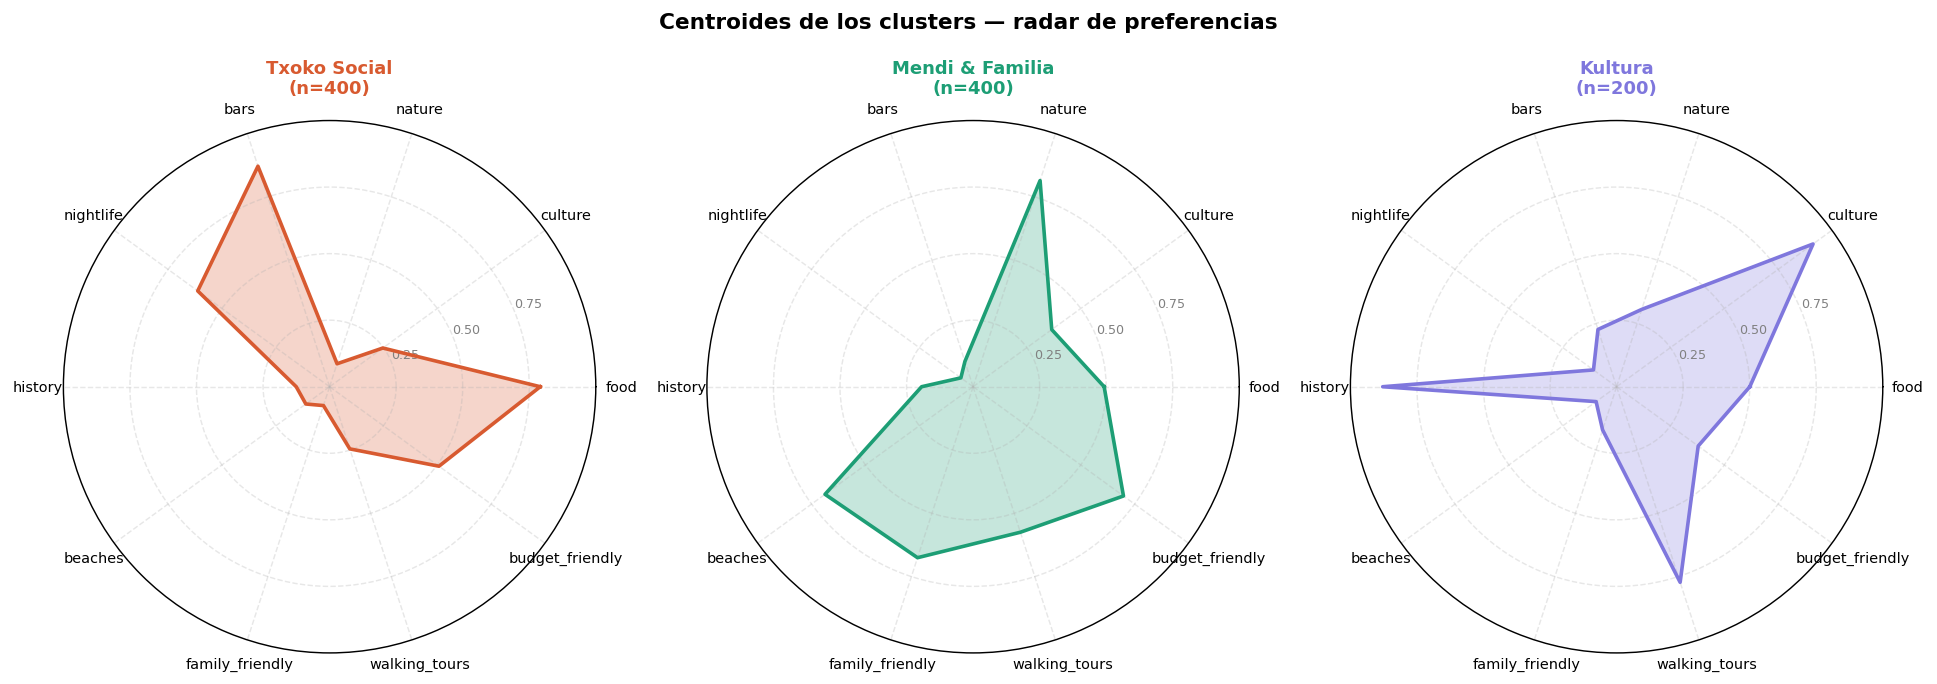

In [10]:
# ── Radar de centroides ──────────────────────────────────────────────────────
DIMS_RADAR = ['food', 'culture', 'nature', 'bars', 'nightlife',
              'history', 'beaches', 'family_friendly', 'walking_tours', 'budget_friendly']
N = len(DIMS_RADAR)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(1, k_optimo, figsize=(5 * k_optimo, 5),
                         subplot_kw=dict(polar=True))
if k_optimo == 1:
    axes = [axes]

for ax, cluster_id in zip(axes, range(k_optimo)):
    nombre = NOMBRE_POR_CLUSTER[cluster_id]
    color  = PALETTE[cluster_id]
    values = df_centroids.iloc[cluster_id][DIMS_RADAR].tolist()
    values += values[:1]
    ax.plot(angles, values, color=color, linewidth=2)
    ax.fill(angles, values, color=color, alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(DIMS_RADAR, size=8)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75])
    ax.set_yticklabels(['0.25', '0.50', '0.75'], size=7, color='gray')
    n = NOMBRES_CLUSTER[cluster_id]['n']
    ax.set_title(f'{nombre}\n(n={n})', fontsize=10, fontweight='bold', pad=15, color=color)

plt.suptitle('Centroides de los clusters — radar de preferencias',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_radar_clusters.png', bbox_inches='tight', dpi=130)
plt.show()


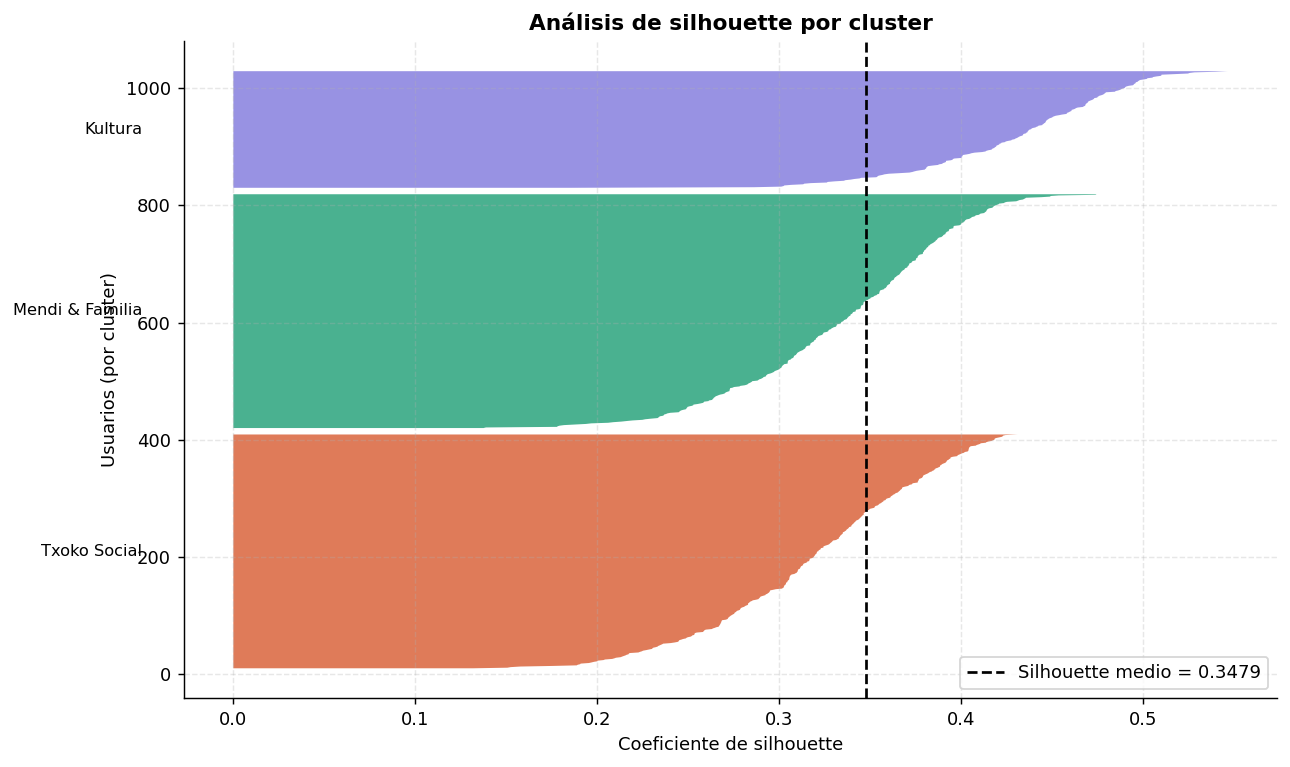

In [11]:
# ── Silhouette por cluster ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

sil_vals = silhouette_samples(X_scaled, labels_final)
y_lower  = 10

for i in range(k_optimo):
    nombre_c = NOMBRE_POR_CLUSTER.get(i, f'Cluster {i}')
    ith_sil  = np.sort(sil_vals[labels_final == i])
    size     = ith_sil.shape[0]
    y_upper  = y_lower + size
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_sil,
                     facecolor=PALETTE[i], edgecolor='none', alpha=0.8)
    ax.text(-0.05, y_lower + size / 2, nombre_c,
            ha='right', va='center', fontsize=9)
    y_lower = y_upper + 10

ax.axvline(sil_final, color='black', linestyle='--', linewidth=1.5,
           label=f'Silhouette medio = {sil_final:.4f}')
ax.set_xlabel('Coeficiente de silhouette')
ax.set_ylabel('Usuarios (por cluster)')
ax.set_title('Análisis de silhouette por cluster', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('fig_silhouette_analysis.png', bbox_inches='tight', dpi=130)
plt.show()


## Función de predicción para producción

Esta función recibe exactamente lo que el usuario introduce en el onboarding y devuelve el cluster asignado. Es la interfaz que usará el endpoint `/recommend` de la API.

**Nota sobre la conversión del vector de producción:**
El usuario real da 3 preferencias binarias + 1 duración + 1 compañía. Antes de pasarlo al modelo, convertimos `duration` y `companion` a sus valores ordinales [0.25–1.0] usando los mismos mapeos que se usaron en la generación sintética. El `StandardScaler` hace el resto: transforma el vector al mismo espacio que aprendió durante el entrenamiento.


In [13]:
def predecir_perfil(preferencias: list, duracion: str, compania: str) -> dict:
    """
    Asigna un usuario nuevo al cluster más cercano.

    Args:
        preferencias : lista con exactamente 3 strings de PREFS
                       ej: ['food', 'bars', 'local_favorites']
        duracion     : una de ['1_dia', '2_3_dias', '4_7_dias', 'mas_de_7']
        compania     : una de ['solo', 'pareja', 'amigos', 'familia']

    Returns:
        dict con cluster_id, perfil, subcategorias recomendadas y vibes
    """
    assert len(preferencias) == 3, "Deben ser exactamente 3 preferencias"
    assert all(p in PREFS for p in preferencias), f"Preferencia no válida: {preferencias}"
    assert duracion in DURATION_MAP,  f"Duración no válida: {duracion}"
    assert compania in COMPANION_MAP, f"Compañía no válida: {compania}"

    # Vector de preferencias binario
    vector_prefs = [1 if p in preferencias else 0 for p in PREFS]

    # duration y companion como valores ordinales (mismo rango que los sintéticos)
    vector_ctx = [DURATION_MAP[duracion], COMPANION_MAP[compania]]

    vector = np.array(vector_prefs + vector_ctx).reshape(1, -1)

    # Escalar con el mismo scaler entrenado en los sintéticos
    vector_scaled = scaler.transform(vector)
    cluster_id    = int(km_final.predict(vector_scaled)[0])
    nombre        = NOMBRE_POR_CLUSTER[cluster_id]
    categorias    = CLUSTER_TO_CATEGORIAS[nombre]

    return {
        'cluster_id':    cluster_id,
        'perfil':        nombre,
        'subcategorias': categorias['subcategorias'],
        'vibes':         categorias['vibes'],
    }


# ── Tests de ejemplo ──────────────────────────────────────────────────────────
test_cases = [
    (['food', 'bars', 'local_favorites'],        'threedays', 'partner'),
    (['food', 'nightlife', 'bars'],              'oneday',    'friends'),
    (['culture', 'history', 'walking_tours'],    'oneweek', 'solo'),
    (['nature', 'beaches', 'budget_friendly'],   'oneweek', 'family'),
    (['family_friendly', 'nature', 'beaches'],   'longstay', 'family'),
]

print("Tests de predicción:\n")
for prefs, dur, comp in test_cases:
    r = predecir_perfil(prefs, dur, comp)
    print(f"  Prefs    : {prefs}")
    print(f"  Duración : {dur} | Compañía : {comp}")
    print(f"  → Perfil : {r['perfil']}  (cluster {r['cluster_id']})")
    print(f"  → Vibes  : {r['vibes']}")
    print()


Tests de predicción:

  Prefs    : ['food', 'bars', 'local_favorites']
  Duración : threedays | Compañía : partner
  → Perfil : Txoko Social  (cluster 0)
  → Vibes  : ['For Foodies', 'Local Favorites', 'Pintxo Crawl']

  Prefs    : ['food', 'nightlife', 'bars']
  Duración : oneday | Compañía : friends
  → Perfil : Txoko Social  (cluster 0)
  → Vibes  : ['For Foodies', 'Local Favorites', 'Pintxo Crawl']

  Prefs    : ['culture', 'history', 'walking_tours']
  Duración : oneweek | Compañía : solo
  → Perfil : Kultura  (cluster 2)
  → Vibes  : ['For Culture Lovers', 'Walking Tours', 'History & Art']

  Prefs    : ['nature', 'beaches', 'budget_friendly']
  Duración : oneweek | Compañía : family
  → Perfil : Mendi & Familia  (cluster 1)
  → Vibes  : ['For the Outdoors', 'Family Day', 'Active Weekend']

  Prefs    : ['family_friendly', 'nature', 'beaches']
  Duración : longstay | Compañía : family
  → Perfil : Mendi & Familia  (cluster 1)
  → Vibes  : ['For the Outdoors', 'Family Day', 'Activ

## Guardar modelo y metadatos


In [16]:
import pickle, json, os

os.makedirs('modelos', exist_ok=True)

modelo_package = {
    'kmeans':                km_final,
    'scaler':                scaler,
    'dims':                  DIMS,
    'prefs':                 PREFS,
    'duration_map':          DURATION_MAP,
    'companion_map':         COMPANION_MAP,
    'nombre_por_cluster':    NOMBRE_POR_CLUSTER,
    'cluster_to_categorias': CLUSTER_TO_CATEGORIAS,
}

with open('../model/modelo_clustering.pkl', 'wb') as f:
    pickle.dump(modelo_package, f)

resultados = {
    'modelo':                 'KMeans',
    'version':                '2.0',
    'k_optimo':               int(k_optimo),
    'silhouette':             round(float(sil_final), 4),
    'n_usuarios_sinteticos':  len(df_users),
    'dims':                   DIMS,
    'nota_diseno': (
        'Sintéticos con distribución Beta continua para maximizar separabilidad. '
        'Producción: 3 prefs binarias + duration/companion ordinales [0.25-1.0]. '
        'El StandardScaler normaliza ambos al mismo espacio.'
    ),
    'clusters': {
        str(cid): {
            'nombre': NOMBRE_POR_CLUSTER[cid],
            'n':      int(NOMBRES_CLUSTER[cid]['n']),
            'top5_prefs': {k: round(float(v), 3)
                           for k, v in NOMBRES_CLUSTER[cid]['top5'].items()},
        }
        for cid in range(k_optimo)
    },
    'cluster_to_categorias': CLUSTER_TO_CATEGORIAS,
}

with open('../model/resultados_modelo2.json', 'w', encoding='utf-8') as f:
    json.dump(resultados, f, indent=2, ensure_ascii=False)

print("✓ Modelo guardado en  modelos/modelo_clustering.pkl")
print("✓ Metadatos guardados en modelos/resultados_modelo2.json")
print()
print(f"  K óptimo   : {k_optimo}")
print(f"  Silhouette : {sil_final:.4f}")
print(f"  Dims       : {len(DIMS)}")


✓ Modelo guardado en  modelos/modelo_clustering.pkl
✓ Metadatos guardados en modelos/resultados_modelo2.json

  K óptimo   : 3
  Silhouette : 0.3479
  Dims       : 17


## Conclusiones

**Resultado del clustering:** KMeans con K=3 produce tres perfiles interpretables que reflejan los arquetipos de usuario de Aupa:
- **Txoko Social** (gastro + nocturno): comparten preferencias por bars y food — son estadísticamente indistinguibles porque el espacio de preferencias los solapa, y el modelo los fusiona correctamente.
- **Mendi & Familia** (naturaleza + familiar): comparten nature y beaches — misma lógica.
- **Kultura** (cultural): dimensiones únicas (culture, history, walking_tours) que no aparecen con igual intensidad en ningún otro perfil — forma su propio cluster con total claridad.

**Decisión de diseño documentada:** los datos sintéticos usan distribuciones Beta continuas para maximizar la separabilidad. En producción, el vector binario del usuario se convierte al mismo rango [0,1] antes de escalar, garantizando compatibilidad con el modelo entrenado.

**Limitaciones honestas:**
- Los clusters reflejan los arquetipos que hemos diseñado nosotros. Si los usuarios reales tienen perfiles distintos, el modelo necesitará reentrenarse con datos reales.
- Con usuarios reales, la métrica de validación principal pasará a ser el engagement: ¿los usuarios de un perfil interactúan con los lugares recomendados para ese perfil?

**Siguiente paso en producción:** cuando la app acumule suficientes interacciones reales, se reemplaza `df_users` por datos reales y se reentrena. La función `predecir_perfil()` no cambia.
